# 💳 AI-Powered Fraud Detection & Financial Risk Intelligence System

## 📌 Project Overview

This project aims to develop an AI-powered Machine Learning system that detects potentially fraudulent financial transactions.

The system analyzes transaction-related features and classifies each transaction as either **Genuine** or **Fraudulent**. Since fraudulent transactions are much less common than genuine transactions, the project also focuses on handling **imbalanced data** effectively.

Multiple Machine Learning techniques will be explored and evaluated, including Logistic Regression, Random Forest, and XGBoost. The best-performing model will be selected using appropriate evaluation metrics such as **Precision, Recall, F1-Score, Confusion Matrix, and ROC-AUC**.

The final trained model will be saved and integrated into a **Streamlit web application**, allowing users to enter transaction information and receive a real-time fraud prediction and risk assessment.

## 🎯 Project Objectives

* Detect fraudulent financial transactions.
* Analyze and understand transaction patterns.
* Handle highly imbalanced transaction data.
* Apply feature engineering and preprocessing techniques.
* Use SMOTE to address class imbalance.
* Build an ML Pipeline for consistent preprocessing and prediction.
* Compare multiple Machine Learning models.
* Optimize the best-performing model.
* Evaluate the model using fraud-focused metrics.
* Save the trained model for future predictions.
* Build a Streamlit application for real-time fraud detection.

## 🛠️ Technologies

* Python
* Pandas
* NumPy
* Matplotlib
* Seaborn
* Scikit-learn
* imbalanced-learn
* XGBoost
* Joblib
* Streamlit

## 🔄 Project Workflow

Dataset → Data Understanding → EDA → Data Preprocessing → Feature Engineering → Imbalanced Data Handling → SMOTE → ML Pipeline → Model Training → Model Comparison → Hyperparameter Tuning → Model Evaluation → ROC-AUC → Model Saving → Streamlit Deployment


In [1]:
import pandas as pd

data = pd.read_csv("../data/creditcard.csv")
print(data.head(10))

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   
5   2.0 -0.425966  0.960523  1.141109 -0.168252  0.420987 -0.029728  0.476201   
6   4.0  1.229658  0.141004  0.045371  1.202613  0.191881  0.272708 -0.005159   
7   7.0 -0.644269  1.417964  1.074380 -0.492199  0.948934  0.428118  1.120631   
8   7.0 -0.894286  0.286157 -0.113192 -0.271526  2.669599  3.721818  0.370145   
9   9.0 -0.338262  1.119593  1.044367 -0.222187  0.499361 -0.246761  0.651583   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -

In [2]:
## Check Dataset Size
print("Dataset Shape:", data.shape)

Dataset Shape: (284807, 31)


In [3]:
#Check Column Information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [4]:
#Check Missing Values
print(data.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [5]:
#Check Duplicate Rows
print("Duplicate Rows:", data.duplicated().sum())

Duplicate Rows: 1081


In [6]:
#Check Target Distribution

# Class

0 → Genuine transaction

1 → Fraudulent transaction

In [7]:
print("Class Distribution:")
print(data["Class"].value_counts())

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64


In [8]:
#Check Percentage
print("\nClass Percentage:")
print(data["Class"].value_counts(normalize=True) * 100)

print("\n So this is a highly imbalanced classification dataset.")


Class Percentage:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

 So this is a highly imbalanced classification dataset.


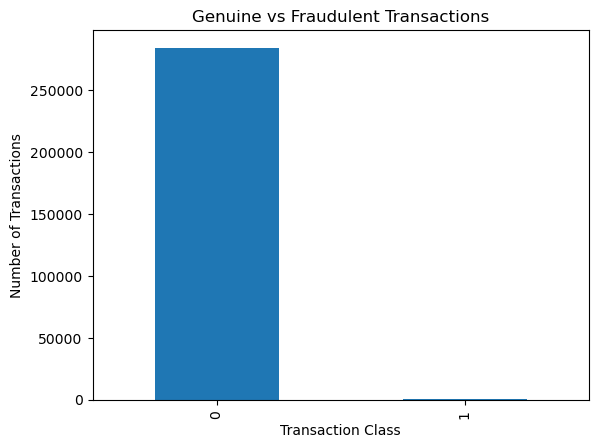

In [9]:
#Visualize Class Distribution
import matplotlib.pyplot as plt

data["Class"].value_counts().plot(kind="bar")

plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")
plt.title("Genuine vs Fraudulent Transactions")

plt.show()

In [10]:
#Understand the Features
print(data.columns)

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')


In [11]:
print(data.describe())

                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.175161e-15  3.384974e-16 -1.379537e-15  2.094852e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   1.021879e-15  1.494498e-15 -5.620335e-16  1.149614e-16 -2.414189e-15   
std    1.380247e+00  1.332271e+00  1.23709

In [12]:
#Check Data Types & Missing Values

print("Data Types:")
print(data.dtypes)

Data Types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


In [13]:
print("\nMissing Values:")
print(data.isnull().sum())


Missing Values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [14]:
print("\nTotal Missing Values:", data.isnull().sum().sum())


Total Missing Values: 0


In [15]:
#Handle Duplicate Rows

duplicates = data[data.duplicated(keep=False)]

print(duplicates["Class"].value_counts())

Class
0    1822
1      32
Name: count, dtype: int64


In [16]:
#remove duplicates

data = data.drop_duplicates().copy()

print("Shape after removing duplicates:", data.shape)

Shape after removing duplicates: (283726, 31)


In [17]:
#Check Fraud Distribution Again

print(data["Class"].value_counts())

Class
0    283253
1       473
Name: count, dtype: int64


In [18]:
print("\nClass Percentage:")
print(data["Class"].value_counts(normalize=True) * 100)


Class Percentage:
Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


## EDA (Exploratory Data Analysis.)

In [19]:
#Transaction Amount

print("Amount Statistics:")
print(data["Amount"].describe())

Amount Statistics:
count    283726.000000
mean         88.472687
std         250.399437
min           0.000000
25%           5.600000
50%          22.000000
75%          77.510000
max       25691.160000
Name: Amount, dtype: float64


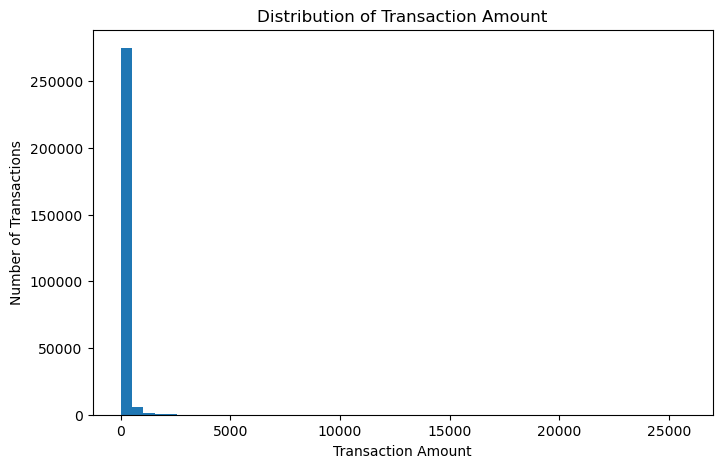

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(data["Amount"], bins=50)

plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")
plt.title("Distribution of Transaction Amount")

plt.show()

In [21]:
#Genuine vs Fraud Amount

print("Genuine Transaction Amount:")
print(data[data["Class"] == 0]["Amount"].describe())

print("\nFraudulent Transaction Amount:")
print(data[data["Class"] == 1]["Amount"].describe())

Genuine Transaction Amount:
count    283253.000000
mean         88.413575
std         250.379023
min           0.000000
25%           5.670000
50%          22.000000
75%          77.460000
max       25691.160000
Name: Amount, dtype: float64

Fraudulent Transaction Amount:
count     473.000000
mean      123.871860
std       260.211041
min         0.000000
25%         1.000000
50%         9.820000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


<Figure size 800x500 with 0 Axes>

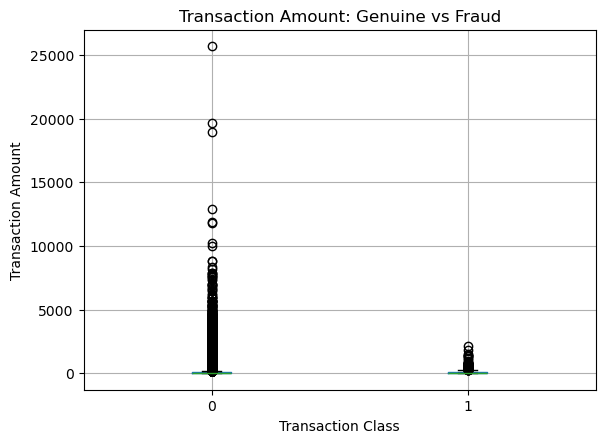

In [22]:
#Compare Genuine vs Fraud Amount

plt.figure(figsize=(8, 5))

data.boxplot(
    column="Amount",
    by="Class"
)

plt.xlabel("Transaction Class")
plt.ylabel("Transaction Amount")
plt.title("Transaction Amount: Genuine vs Fraud")

plt.suptitle("")

plt.show()

In [23]:
#Analyze Time

print(data["Time"].describe())

count    283726.000000
mean      94811.077600
std       47481.047891
min           0.000000
25%       54204.750000
50%       84692.500000
75%      139298.000000
max      172792.000000
Name: Time, dtype: float64


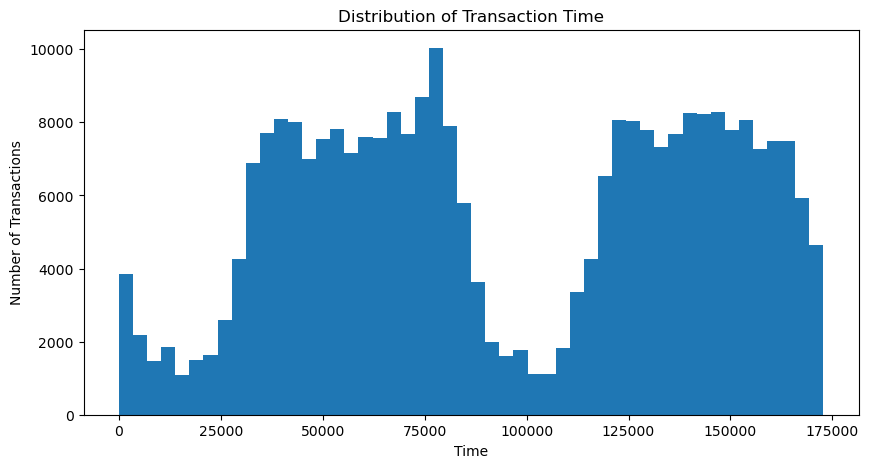

In [24]:
plt.figure(figsize=(10, 5))

plt.hist(data["Time"], bins=50)

plt.xlabel("Time")
plt.ylabel("Number of Transactions")
plt.title("Distribution of Transaction Time")

plt.show()

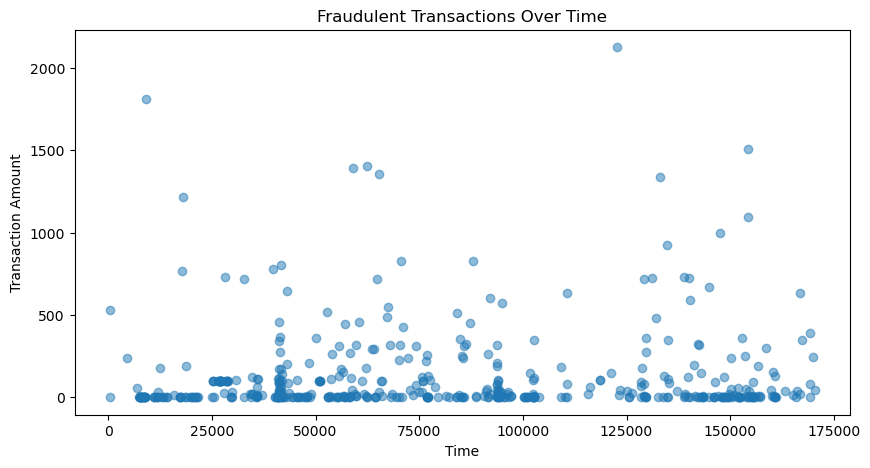

In [25]:
#Fraud Transactions Over Time

fraud = data[data["Class"] == 1]

plt.figure(figsize=(10, 5))

plt.scatter(
    fraud["Time"],
    fraud["Amount"],
    alpha=0.5
)

plt.xlabel("Time")
plt.ylabel("Transaction Amount")
plt.title("Fraudulent Transactions Over Time")

plt.show()

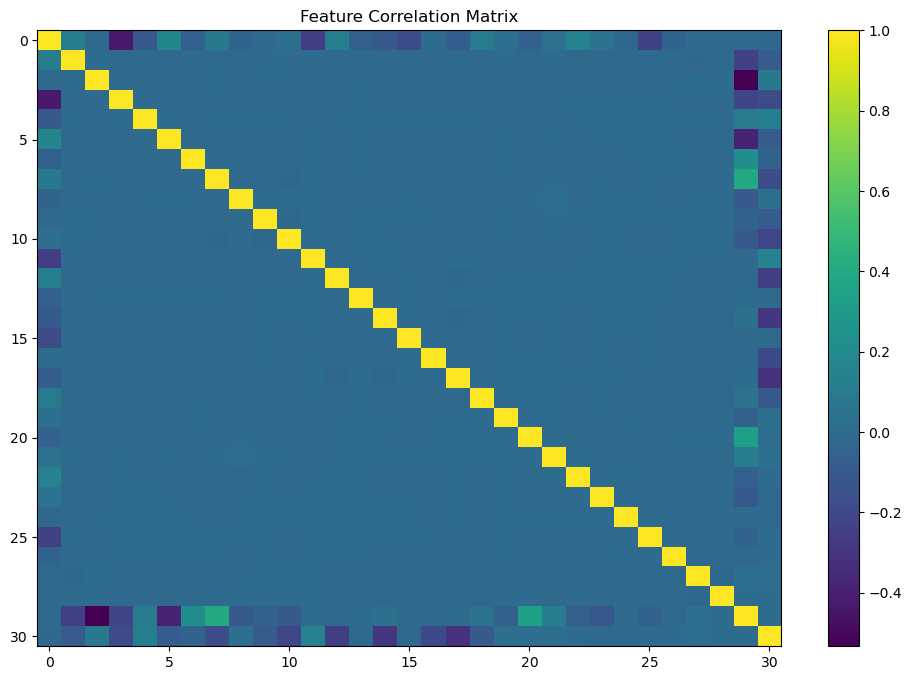

In [26]:
#Feature Correlation

plt.figure(figsize=(12, 8))

correlation = data.corr()

plt.imshow(correlation, aspect="auto")

plt.colorbar()

plt.title("Feature Correlation Matrix")

plt.show()

# Feature Engineering

In [27]:
print(data.columns)

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')


In [28]:
import numpy as np

data["Amount_log"] = np.log1p(data["Amount"])

In [29]:
print(data[["Amount", "Amount_log"]].head())

   Amount  Amount_log
0  149.62    5.014760
1    2.69    1.305626
2  378.66    5.939276
3  123.50    4.824306
4   69.99    4.262539


In [30]:
#Create Time Feature

data["Time_hours"] = data["Time"] / 3600

print(data[["Time", "Time_hours"]].head())

   Time  Time_hours
0   0.0    0.000000
1   0.0    0.000000
2   1.0    0.000278
3   1.0    0.000278
4   2.0    0.000556


In [31]:
print(data.head())
print(data.shape)

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V23       V24       V25       V26       V27  \
0  0.098698  0.363787  ... -0.110474  0.066928  0.128539 -0.189115  0.133558   
1  0.085102 -0.255425  ...  0.101288 -0.339846  0.167170  0.125895 -0.008983   
2  0.247676 -1.514654  ...  0.909412 -0.689281 -0.327642 -0.139097 -0.055353   
3  0.377436 -1.387024  ... -0.190321 -1.175575  0.647376 -0.221929  0.062723   
4 -0.270533  0.817739  ... -0.137458  0.141267 -0.206010  0.502292  0.219422   

        V28  Amount  Class  Amou

In [32]:
#Define X and y

X = data.drop("Class", axis=1)
y = data["Class"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (283726, 32)
y Shape: (283726,)


# Train/Test Split

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [34]:
print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

print("\nTraining Class Distribution:")
print(y_train.value_counts())

print("\nTesting Class Distribution:")
print(y_test.value_counts())

Training Shape: (226980, 32)
Testing Shape: (56746, 32)

Training Class Distribution:
Class
0    226602
1       378
Name: count, dtype: int64

Testing Class Distribution:
Class
0    56651
1       95
Name: count, dtype: int64


# Handling Imbalanced Data with SMOTE

In [35]:
from imblearn.over_sampling import SMOTE

print("SMOTE imported successfully!")

SMOTE imported successfully!


In [36]:
#Create the SMOTE Object

smote = SMOTE(random_state=42)

print("SMOTE object created successfully!")

SMOTE object created successfully!


In [37]:
#Apply SMOTE

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("SMOTE applied successfully!")

SMOTE applied successfully!


In [38]:
#Check SMOTE Result

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Class
0    226602
1       378
Name: count, dtype: int64

After SMOTE:
Class
0    226602
1    226602
Name: count, dtype: int64


# Feature Scaling

In [39]:
#Import StandardScaler

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

print("StandardScaler created successfully!")

StandardScaler created successfully!


In [40]:
scaler.fit(X_train_smote)

print("Scaler fitted successfully!")

Scaler fitted successfully!


In [41]:
#Transform the Training and Test Data

X_train_scaled = scaler.transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

print("Training data scaled:", X_train_scaled.shape)
print("Testing data scaled:", X_test_scaled.shape)

Training data scaled: (453204, 32)
Testing data scaled: (56746, 32)


In [42]:
# Verify Standard Scaling

print("First 5 scaled rows:")
print(X_train_scaled[:5])

print("\nMean:", X_train_scaled.mean())
print("Standard Deviation:", X_train_scaled.std())

First 5 scaled rows:
[[ 1.14913517  0.85987151 -1.02419132  0.23432606 -1.54951576  0.6299544
   2.6896219   0.1791264   0.07217234  0.02289544  1.04142253 -0.79992573
   0.55312343  0.39382586  0.72229392  0.36063159  0.45213183  0.65913994
   0.41157606 -0.57994672 -0.54672688 -0.2169698  -0.10650602  0.35938572
   1.37646303 -0.40656527 -0.43274772 -0.08891327 -0.24175895 -0.28823438
   0.31699984  1.14913517]
 [-0.15093343  0.19752103 -0.05851138  0.68605037 -0.74238008  0.28690306
  -0.13053123  0.55137987  0.04090626  0.02109466  0.55589916 -0.18307071
   1.10970305  1.29992174  0.98021836 -0.2444254   0.74444902  0.54611668
   0.34035481  0.02819466 -0.28563795 -0.26624633 -1.09106131  0.41250242
   1.06141403 -1.20042539 -0.67437767 -0.15443371  0.00691886 -0.40445369
  -0.49195992 -0.15093343]
 [ 0.7940822   0.79834203 -0.52176819  0.24476042 -0.68908829  0.67112313
   0.84720818  0.50767163 -0.09822509  0.7333821   0.55231618 -0.1477245
   0.94660026  0.50790315  0.63983527  

# Train the first ML model: Logistic Regression.

In [43]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=1000, random_state=42)

model_lr.fit(X_train_scaled, y_train_smote)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [44]:
y_pred_lr = model_lr.predict(X_test_scaled)

print("Predictions completed!")
print(y_pred_lr[:20])

Predictions completed!
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


# Confusion Matrix & Classification Report 📊

In [45]:
from sklearn.metrics import confusion_matrix, classification_report

cm_lr = confusion_matrix(y_test, y_pred_lr)

print("Confusion Matrix:")
print(cm_lr)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Confusion Matrix:
[[56161   490]
 [   14    81]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56651
           1       0.14      0.85      0.24        95

    accuracy                           0.99     56746
   macro avg       0.57      0.92      0.62     56746
weighted avg       1.00      0.99      0.99     56746



In [46]:
# ROC-AUC 

from sklearn.metrics import roc_auc_score, roc_curve

# Fraud probability
y_prob_lr = model_lr.predict_proba(X_test_scaled)[:, 1]

# ROC-AUC
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression ROC-AUC:", roc_auc_lr)

Logistic Regression ROC-AUC: 0.960045393354881


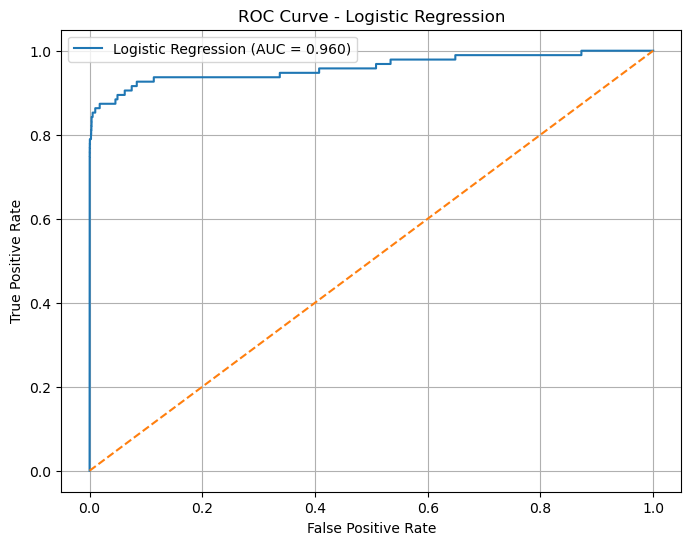

In [47]:
#Plot ROC Curve 📈

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, y_prob_lr)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {roc_auc_lr:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.grid()
plt.show()

# Second Model is Random Forest Classifier 🌳

In [49]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model_rf.fit(X_train_scaled, y_train_smote)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [52]:
#Random Forest Prediction 🌳

y_pred_rf = model_rf.predict(X_test_scaled)

print("Random Forest predictions completed!")
print(y_pred_rf[:20])

Random Forest predictions completed!
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [53]:
#Random Forest Evaluation 📊

from sklearn.metrics import confusion_matrix, classification_report

cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Confusion Matrix:")
print(cm_rf)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Confusion Matrix:
[[56573    78]
 [   17    78]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.50      0.82      0.62        95

    accuracy                           1.00     56746
   macro avg       0.75      0.91      0.81     56746
weighted avg       1.00      1.00      1.00     56746



In [54]:
#Random Forest ROC-AUC

from sklearn.metrics import roc_auc_score, roc_curve

y_prob_rf = model_rf.predict_proba(X_test_scaled)[:, 1]

roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest ROC-AUC:", roc_auc_rf)

Random Forest ROC-AUC: 0.9695242059182306


# XGBoost Classifier 🚀

In [55]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.3.0


In [56]:
from xgboost import XGBClassifier

model_xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

model_xgb.fit(X_train_scaled, y_train_smote)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


In [57]:
#XGBoost Prediction

y_pred_xgb = model_xgb.predict(X_test_scaled)

print("XGBoost predictions completed!")
print(y_pred_xgb[:20])

XGBoost predictions completed!
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [58]:
#XGBoost Evaluation 📊

from sklearn.metrics import confusion_matrix, classification_report

cm_xgb = confusion_matrix(y_test, y_pred_xgb)

print("Confusion Matrix:")
print(cm_xgb)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

Confusion Matrix:
[[56608    43]
 [   19    76]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.64      0.80      0.71        95

    accuracy                           1.00     56746
   macro avg       0.82      0.90      0.85     56746
weighted avg       1.00      1.00      1.00     56746



In [59]:
#XGBoost ROC-AUC

from sklearn.metrics import roc_auc_score, roc_curve

y_prob_xgb = model_xgb.predict_proba(X_test_scaled)[:, 1]

roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print("XGBoost ROC-AUC:", roc_auc_xgb)

XGBoost ROC-AUC: 0.9736878338190713


# Hyperparameter Tuning

In [60]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

print("Parameter grid created successfully!")

Parameter grid created successfully!


In [61]:
#Train XGBoost with RandomizedSearchCV

from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

xgb_base = XGBClassifier(
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=10,
    scoring="f1",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train_scaled, y_train_smote)

print("Hyperparameter tuning completed!")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Hyperparameter tuning completed!


In [62]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV F1 Score:")
print(random_search.best_score_)

Best Parameters:
{'subsample': 1.0, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.2, 'colsample_bytree': 1.0}

Best CV F1 Score:
0.9998720393406048


# Get the Best Tuned Model

In [63]:
best_xgb = random_search.best_estimator_

print("Best XGBoost model selected successfully!")

Best XGBoost model selected successfully!


In [64]:
y_pred_best_xgb = best_xgb.predict(X_test_scaled)

print("Tuned XGBoost predictions completed!")

Tuned XGBoost predictions completed!


# Evaluate the Tuned XGBoost Model

In [65]:
from sklearn.metrics import confusion_matrix, classification_report

cm_best_xgb = confusion_matrix(y_test, y_pred_best_xgb)

print("Tuned XGBoost Confusion Matrix:")
print(cm_best_xgb)

print("\nTuned XGBoost Classification Report:")
print(classification_report(y_test, y_pred_best_xgb))

Tuned XGBoost Confusion Matrix:
[[56641    10]
 [   19    76]]

Tuned XGBoost Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.88      0.80      0.84        95

    accuracy                           1.00     56746
   macro avg       0.94      0.90      0.92     56746
weighted avg       1.00      1.00      1.00     56746



In [66]:
#Tuned XGBoost ROC-AUC

from sklearn.metrics import roc_auc_score, roc_curve

y_prob_best_xgb = best_xgb.predict_proba(X_test_scaled)[:, 1]

roc_auc_best_xgb = roc_auc_score(
    y_test,
    y_prob_best_xgb
)

print("Tuned XGBoost ROC-AUC:", roc_auc_best_xgb)

Tuned XGBoost ROC-AUC: 0.9723154420091995


# Save the Best Model

In [68]:
# save the tuned XGBoost model.

import joblib

joblib.dump(
    best_xgb,
    "../models/fraud_detection_xgb.pkl"
)

print("Best XGBoost model saved successfully!")

Best XGBoost model saved successfully!


# Load the Saved Model

In [69]:
import joblib

loaded_model = joblib.load(
    "../models/fraud_detection_xgb.pkl"
)

print("Model loaded successfully!")

Model loaded successfully!


# Test the Loaded Model

In [70]:
loaded_predictions = loaded_model.predict(X_test_scaled)

print("Predictions from loaded model:")
print(loaded_predictions[:20])

Predictions from loaded model:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [71]:
print(
    "Predictions match:",
    (loaded_predictions == y_pred_best_xgb).all()
)

Predictions match: True


# Create a Fraud Prediction Function

In [72]:
def predict_fraud(transaction_data):
    
    prediction = loaded_model.predict(transaction_data)[0]
    probability = loaded_model.predict_proba(transaction_data)[0][1]

    if prediction == 1:
        result = "Fraud"
    else:
        result = "Genuine"

    return result, probability

In [73]:
sample_transaction = X_test_scaled[0].reshape(1, -1)

result, probability = predict_fraud(sample_transaction)

print("Prediction:", result)
print("Fraud Probability:", probability)

Prediction: Genuine
Fraud Probability: 2.1781166e-07


# Build the Production ML Pipeline

In [74]:
#create the pipeline

from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

final_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("model", XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.2,
        subsample=1.0,
        colsample_bytree=1.0,
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss"
    ))
])

print("Production pipeline created successfully!")

Production pipeline created successfully!


In [75]:
#Train the Production ML Pipeline

final_pipeline.fit(X_train, y_train)

print("Production pipeline trained successfully!")

Production pipeline trained successfully!


In [76]:
#Evaluate the Production Pipeline

y_pred_pipeline = final_pipeline.predict(X_test)

print("Prediction completed!")

Prediction completed!


In [77]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_pipeline))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.75      0.80      0.78        95

    accuracy                           1.00     56746
   macro avg       0.88      0.90      0.89     56746
weighted avg       1.00      1.00      1.00     56746



In [78]:
from sklearn.metrics import confusion_matrix

cm_pipeline = confusion_matrix(y_test, y_pred_pipeline)

print(cm_pipeline)

[[56626    25]
 [   19    76]]


In [79]:
from sklearn.metrics import roc_auc_score

y_prob_pipeline = final_pipeline.predict_proba(X_test)[:, 1]

roc_auc_pipeline = roc_auc_score(
    y_test,
    y_prob_pipeline
)

print("Production Pipeline ROC-AUC:", roc_auc_pipeline)

Production Pipeline ROC-AUC: 0.9722801381310684


# Save the Complete Production Pipeline

In [80]:
import joblib

joblib.dump(
    final_pipeline,
    "../models/fraud_detection_pipeline.pkl"
)

print("Production pipeline saved successfully!")

Production pipeline saved successfully!


In [81]:
import os

print(os.path.exists("../models/fraud_detection_pipeline.pkl"))

True


# Load & Verify the Saved Pipeline

In [82]:
import joblib

loaded_pipeline = joblib.load(
    "../models/fraud_detection_pipeline.pkl"
)

print("Production pipeline loaded successfully!")

Production pipeline loaded successfully!


In [83]:
loaded_predictions = loaded_pipeline.predict(X_test)

print("Predictions completed!")

Predictions completed!


In [84]:
print(
    (loaded_predictions == y_pred_pipeline).all()
)

True


In [85]:
import pandas as pd
import zipfile

# Original dataset
data = pd.read_csv("../data/creditcard.csv")

# Take 10,000 transactions
sample_data = data.sample(
    n=10000,
    random_state=42
)

# Save CSV
sample_data.to_csv(
    "../data/sample_10000_transactions.csv",
    index=False
)

# Create ZIP
with zipfile.ZipFile(
    "../data/sample_10000_transactions.zip",
    "w",
    zipfile.ZIP_DEFLATED
) as zip_file:

    zip_file.write(
        "../data/sample_10000_transactions.csv",
        arcname="sample_10000_transactions.csv"
    )

print("10,000 transaction dataset created successfully!")
print(sample_data.shape)

10,000 transaction dataset created successfully!
(10000, 31)
